# Benchmark PyVRP x PuLP

Notebook separado do PoC de apresentacao. Aqui o foco e um experimento analitico por amostragem aleatoria a partir de `operacao_sob_pressao`, com leitura de medias, dispersao, erro relativo da funcao objetivo e uma rodada exaustiva final com 100% das ordens.

In [1]:
from pathlib import Path
from IPython.display import Image, Markdown, display

PROJECT_ROOT = next(parent for parent in [Path.cwd(), *Path.cwd().parents] if (parent / 'pyproject.toml').exists())
NOTEBOOK_DIR = PROJECT_ROOT / 'notebook'
import sys
if str(PROJECT_ROOT / 'src') not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT / 'src'))
if str(NOTEBOOK_DIR) not in sys.path:
    sys.path.insert(0, str(NOTEBOOK_DIR))

from benchmark_workbench_support import (
    build_benchmark_takeaway,
    full_run_route_sequences,
    load_benchmark_summary,
    rows_to_markdown_table,
    run_randomized_pressure_benchmark,
    summarize_full_run,
    summarize_full_run_by_class,
    summarize_pulp_viability,
    summarize_relative_objective_errors,
    summarize_records,
)

BASE_SCENARIO = 'operacao_sob_pressao'
ORDER_SHARES = (0.20, 0.40, 0.60, 0.80)
REPETITIONS = 5
PYVRP_MAX_ITERATIONS = 5000
PULP_TIME_LIMIT_SECONDS = 600
FULL_RUN_PULP_TIME_LIMIT_SECONDS = 3000
OUTPUT_DIR = PROJECT_ROOT / 'data' / 'benchmarks' / 'operacao_sob_pressao_subsample'
WITH_BASEMAP = False
display(Markdown(
    f'**Benchmark ativo**: cenario=`{BASE_SCENARIO}`, shares=`{ORDER_SHARES}`, repeticoes=`{REPETITIONS}`, rodada_exaustiva=`100%`'
))

**Benchmark ativo**: cenario=`operacao_sob_pressao`, shares=`(0.2, 0.4, 0.6, 0.8)`, repeticoes=`5`, rodada_exaustiva=`100%`

## 1. Qual recorte comparavel esta sendo executado?

In [2]:
{
    'base_scenario': BASE_SCENARIO,
    'order_shares_pct': [int(item * 100) for item in ORDER_SHARES],
    'repetitions': REPETITIONS,
    'pyvrp_max_iterations': PYVRP_MAX_ITERATIONS,
    'pulp_time_limit_seconds': PULP_TIME_LIMIT_SECONDS,
    'full_run_pulp_time_limit_seconds': FULL_RUN_PULP_TIME_LIMIT_SECONDS,
    'sampling_policy': 'estratificada por classe_operacional com ordens aleatorias por repeticao',
    'full_run_policy': 'rodada unica, 100% das ordens, fora das medias principais',
    'protocol_path': PROJECT_ROOT / 'docs' / 'benchmark' / 'protocolo-experimental.md',
    'output_dir': OUTPUT_DIR,
}

{'base_scenario': 'operacao_sob_pressao',
 'order_shares_pct': [20, 40, 60, 80],
 'repetitions': 5,
 'pyvrp_max_iterations': 5000,
 'pulp_time_limit_seconds': 600,
 'full_run_pulp_time_limit_seconds': 3000,
 'sampling_policy': 'estratificada por classe_operacional com ordens aleatorias por repeticao',
 'full_run_policy': 'rodada unica, 100% das ordens, fora das medias principais',
 'protocol_path': PosixPath('/home/thiagobibianodasilva/Documentos/aredes-roteirizacao-numerario/docs/benchmark/protocolo-experimental.md'),
 'output_dir': PosixPath('/home/thiagobibianodasilva/Documentos/aredes-roteirizacao-numerario/data/benchmarks/operacao_sob_pressao_subsample')}

## 2. Executar o benchmark e consolidar os artefatos

In [3]:
RUN = run_randomized_pressure_benchmark(
    base_scenario=BASE_SCENARIO,
    order_shares=ORDER_SHARES,
    repetitions=REPETITIONS,
    pyvrp_max_iterations=PYVRP_MAX_ITERATIONS,
    pulp_time_limit_seconds=PULP_TIME_LIMIT_SECONDS,
    full_run_pulp_time_limit_seconds=FULL_RUN_PULP_TIME_LIMIT_SECONDS,
    output_dir=OUTPUT_DIR,
    with_basemap=WITH_BASEMAP,
)
SUMMARY = load_benchmark_summary(RUN.summary_path)
FULL_RUN = RUN.full_run
{'results_csv': str(RUN.results_path), 'summary_json': str(RUN.summary_path), 'plots_dir': str(RUN.plots_dir)}

{'results_csv': '/home/thiagobibianodasilva/Documentos/aredes-roteirizacao-numerario/data/benchmarks/operacao_sob_pressao_subsample/results.csv',
 'summary_json': '/home/thiagobibianodasilva/Documentos/aredes-roteirizacao-numerario/data/benchmarks/operacao_sob_pressao_subsample/summary.json',
 'plots_dir': '/home/thiagobibianodasilva/Documentos/aredes-roteirizacao-numerario/data/benchmarks/operacao_sob_pressao_subsample/plots'}

## 3. Quais medias surgiram por percentual de ordens?

In [4]:
display(Markdown(rows_to_markdown_table(summarize_records(SUMMARY['aggregates']))))

| Solver | Escala | Repeticoes | Tempo médio (s) | DP tempo (s) | FO média | DP FO | Atendimento médio (%) | Viaturas médias | Viabilidade (%) |
| --- | --- | --- | --- | --- | --- | --- | --- | --- | --- |
| PyVRP | 20% das ordens | 5 | 0.3606 | 0.0387 | 12262.32 | 6268.98 | 100.00 | 3.60 | 100.0 |
| PuLP | 20% das ordens | 5 | 0.3499 | 0.1104 | 11461.86 | 5992.80 | 100.00 | 3.20 | 100.0 |
| PyVRP | 40% das ordens | 5 | 0.5910 | 0.0298 | 18675.16 | 3373.65 | 100.00 | 6.40 | 100.0 |
| PuLP | 40% das ordens | 5 | 3.6697 | 0.6632 | 17847.83 | 2926.34 | 100.00 | 5.60 | 100.0 |
| PyVRP | 60% das ordens | 5 | 0.9425 | 0.0053 | 34587.16 | 5535.55 | 100.00 | 8.60 | 100.0 |
| PuLP | 60% das ordens | 5 | 20.1619 | 8.3857 | 33541.45 | 6013.67 | 100.00 | 7.60 | 100.0 |
| PyVRP | 80% das ordens | 5 | 1.4300 | 0.0400 | 45121.13 | 2644.45 | 100.00 | 10.80 | 100.0 |
| PuLP | 80% das ordens | 5 | 114.0907 | 40.8159 | 43647.79 | 1739.16 | 100.00 | 9.00 | 100.0 |

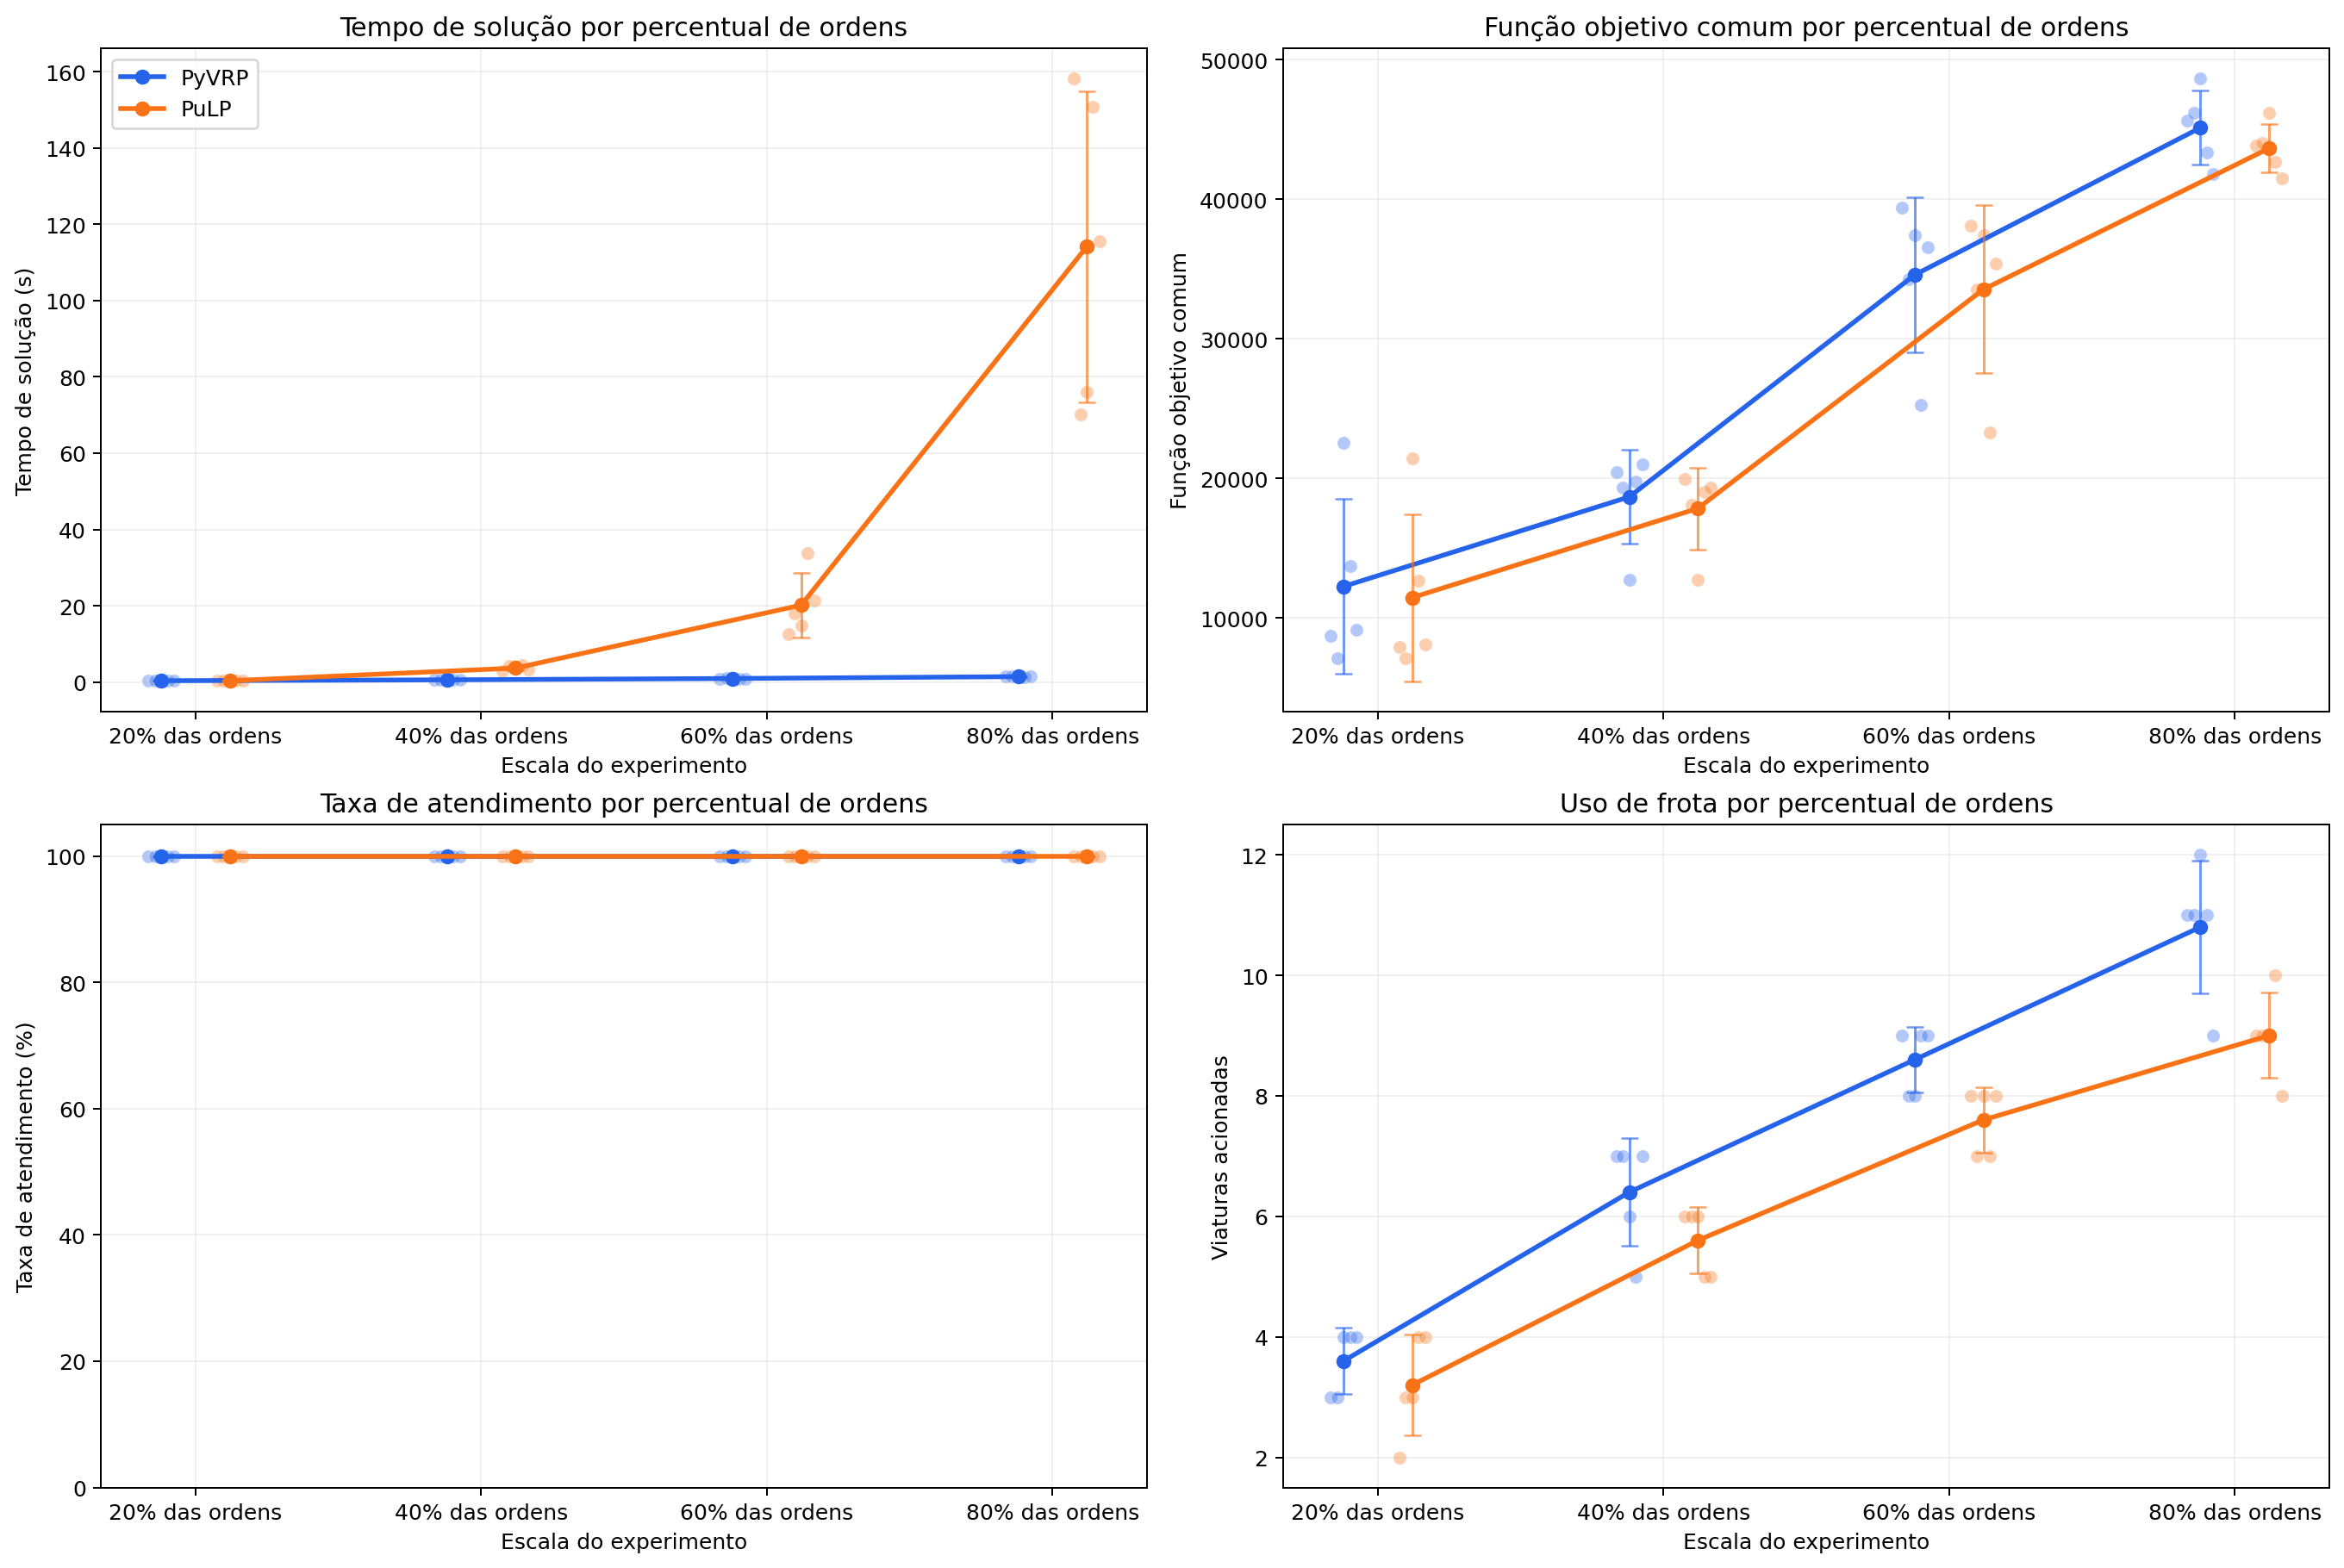

In [5]:
Image(filename=str(OUTPUT_DIR / 'plots' / 'painel_tendencias.png'))

## 4. Como a dispersao se comporta nas repeticoes?

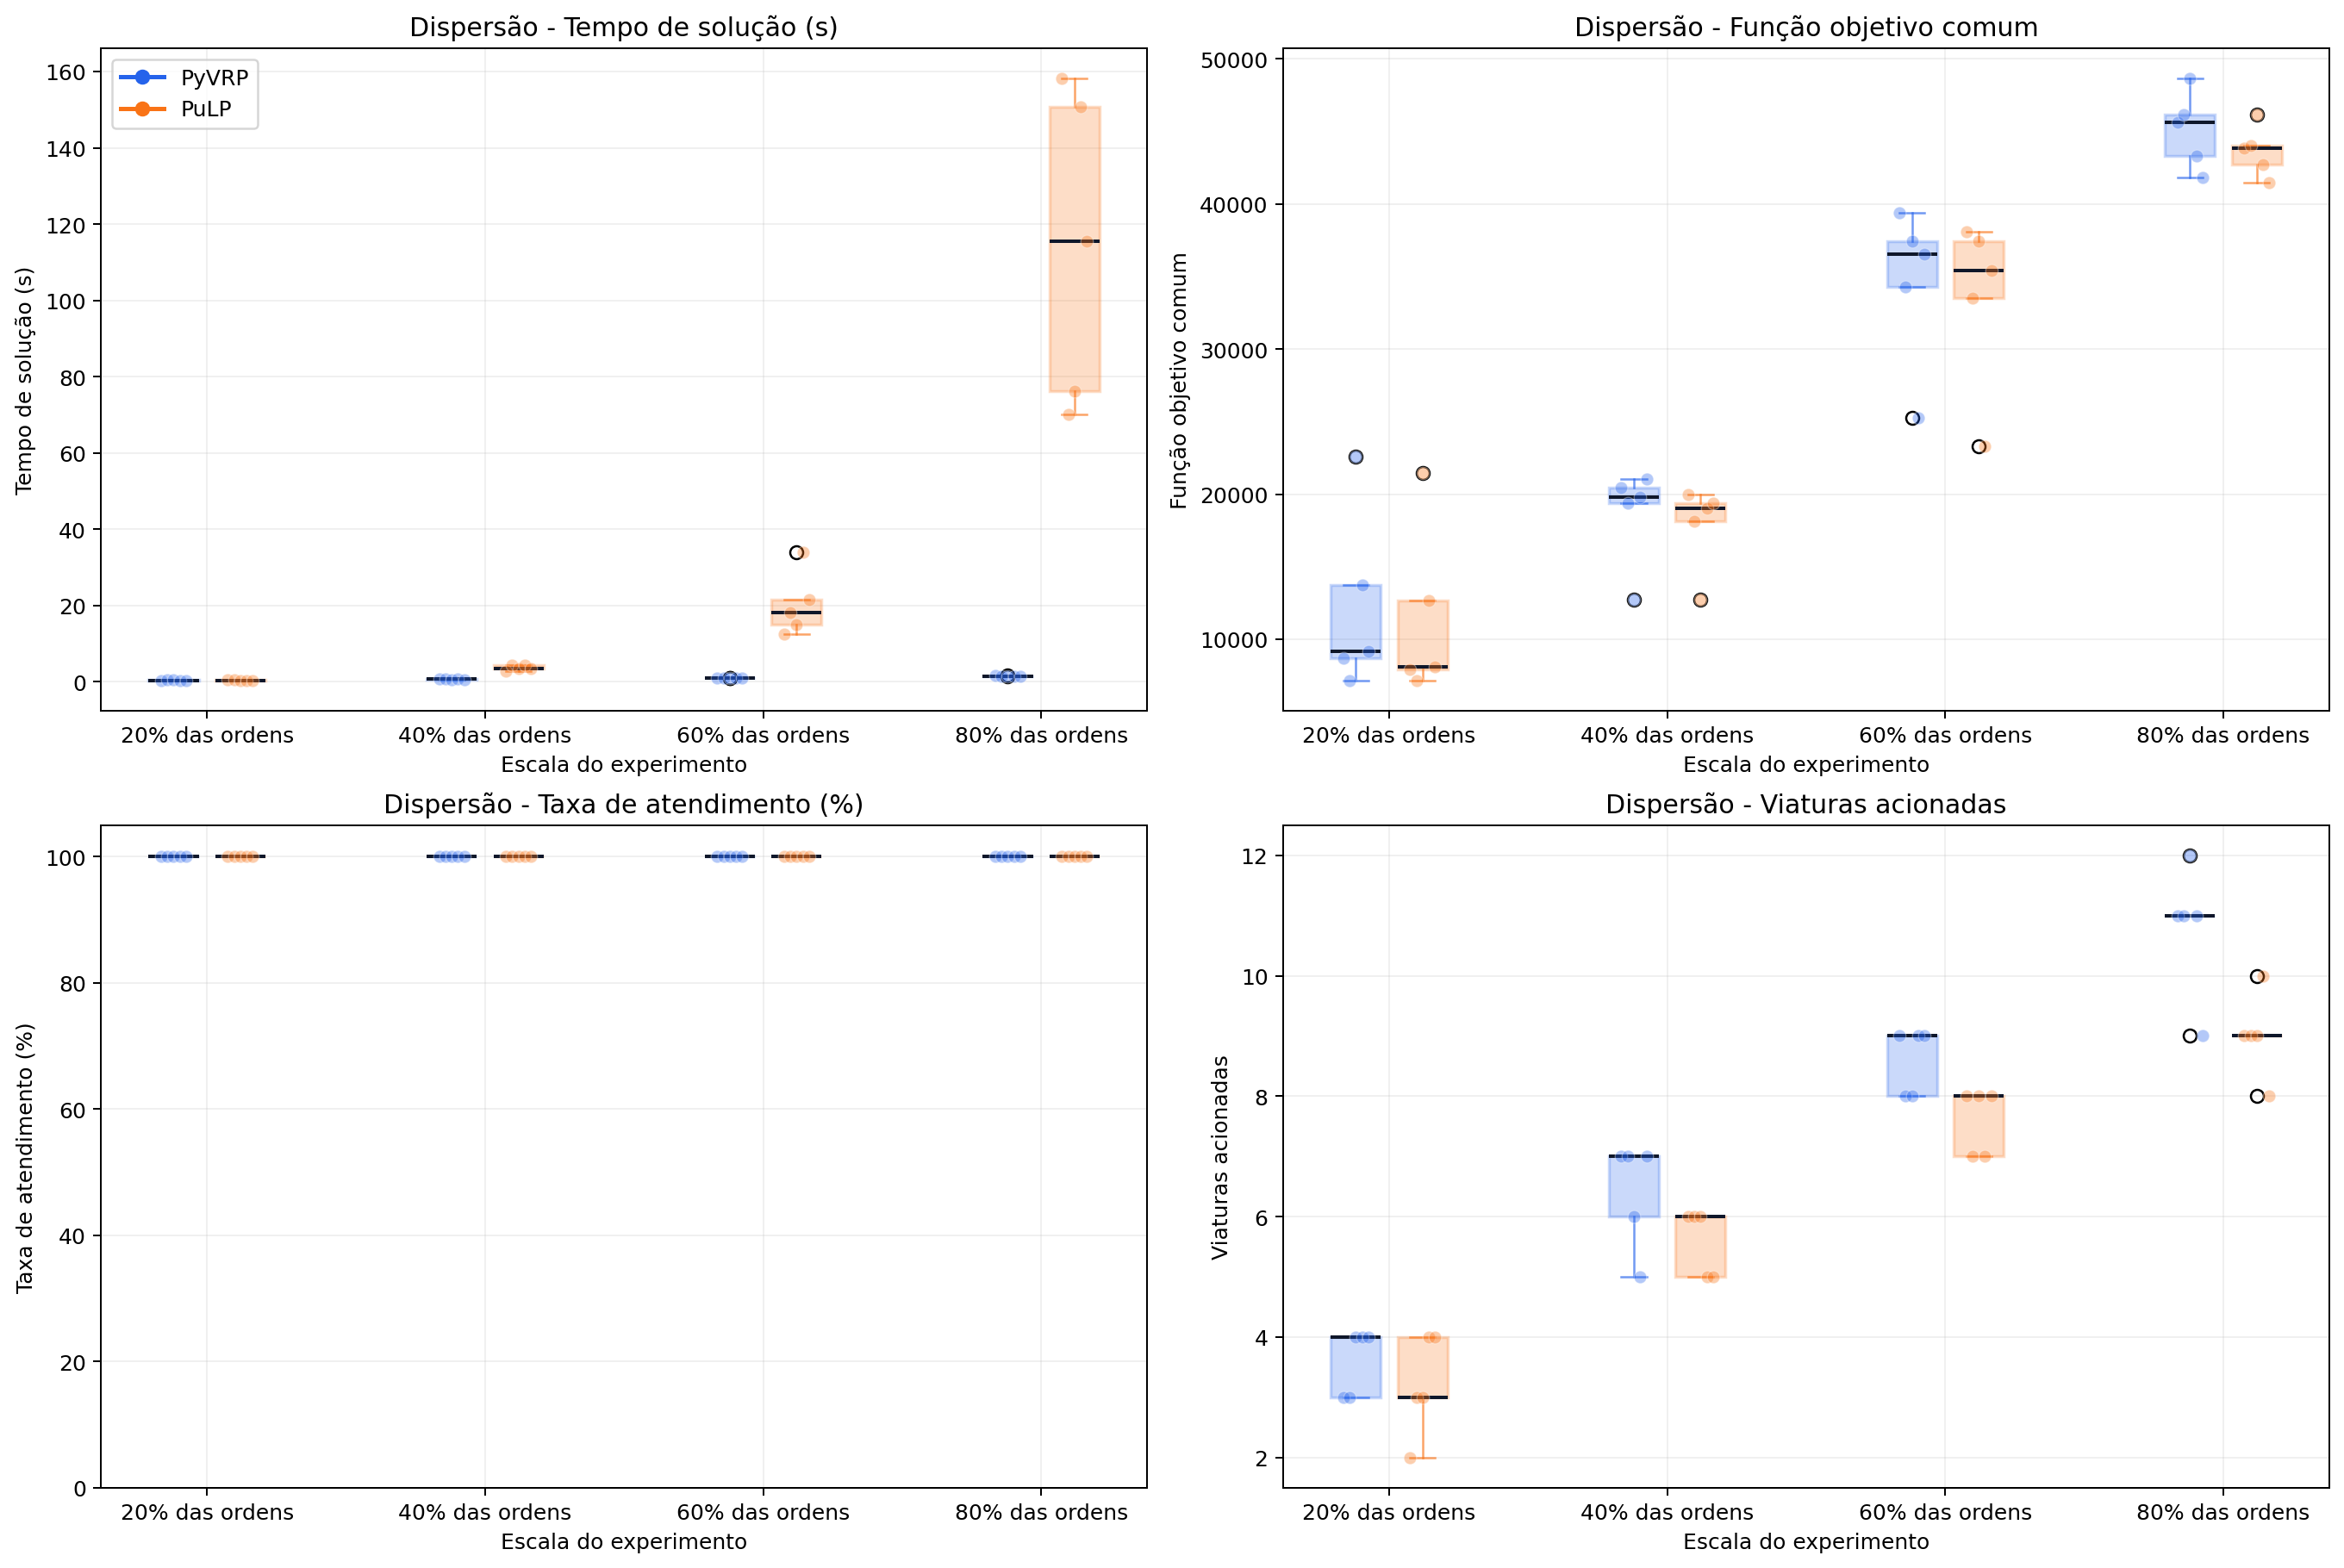

In [6]:
Image(filename=str(OUTPUT_DIR / 'plots' / 'painel_dispersao.png'))

## 5. Qual foi o erro relativo da funcao objetivo em relacao ao PuLP?

In [7]:
display(Markdown(rows_to_markdown_table(summarize_relative_objective_errors(SUMMARY['relative_objective_error_records']))))

| Escala | Referencias PuLP validas | Erro relativo médio da FO (%) | Erro relativo mediano (%) | Erro relativo maximo (%) |
| --- | --- | --- | --- | --- |
| 20% das ordens | 5/5 | 7.2450 | 8.3164 | 13.0291 |
| 40% das ordens | 5/5 | 4.3574 | 3.8526 | 8.6471 |
| 60% das ordens | 5/5 | 3.5057 | 3.3420 | 8.4555 |
| 80% das ordens | 5/5 | 3.3154 | 4.1393 | 5.3380 |

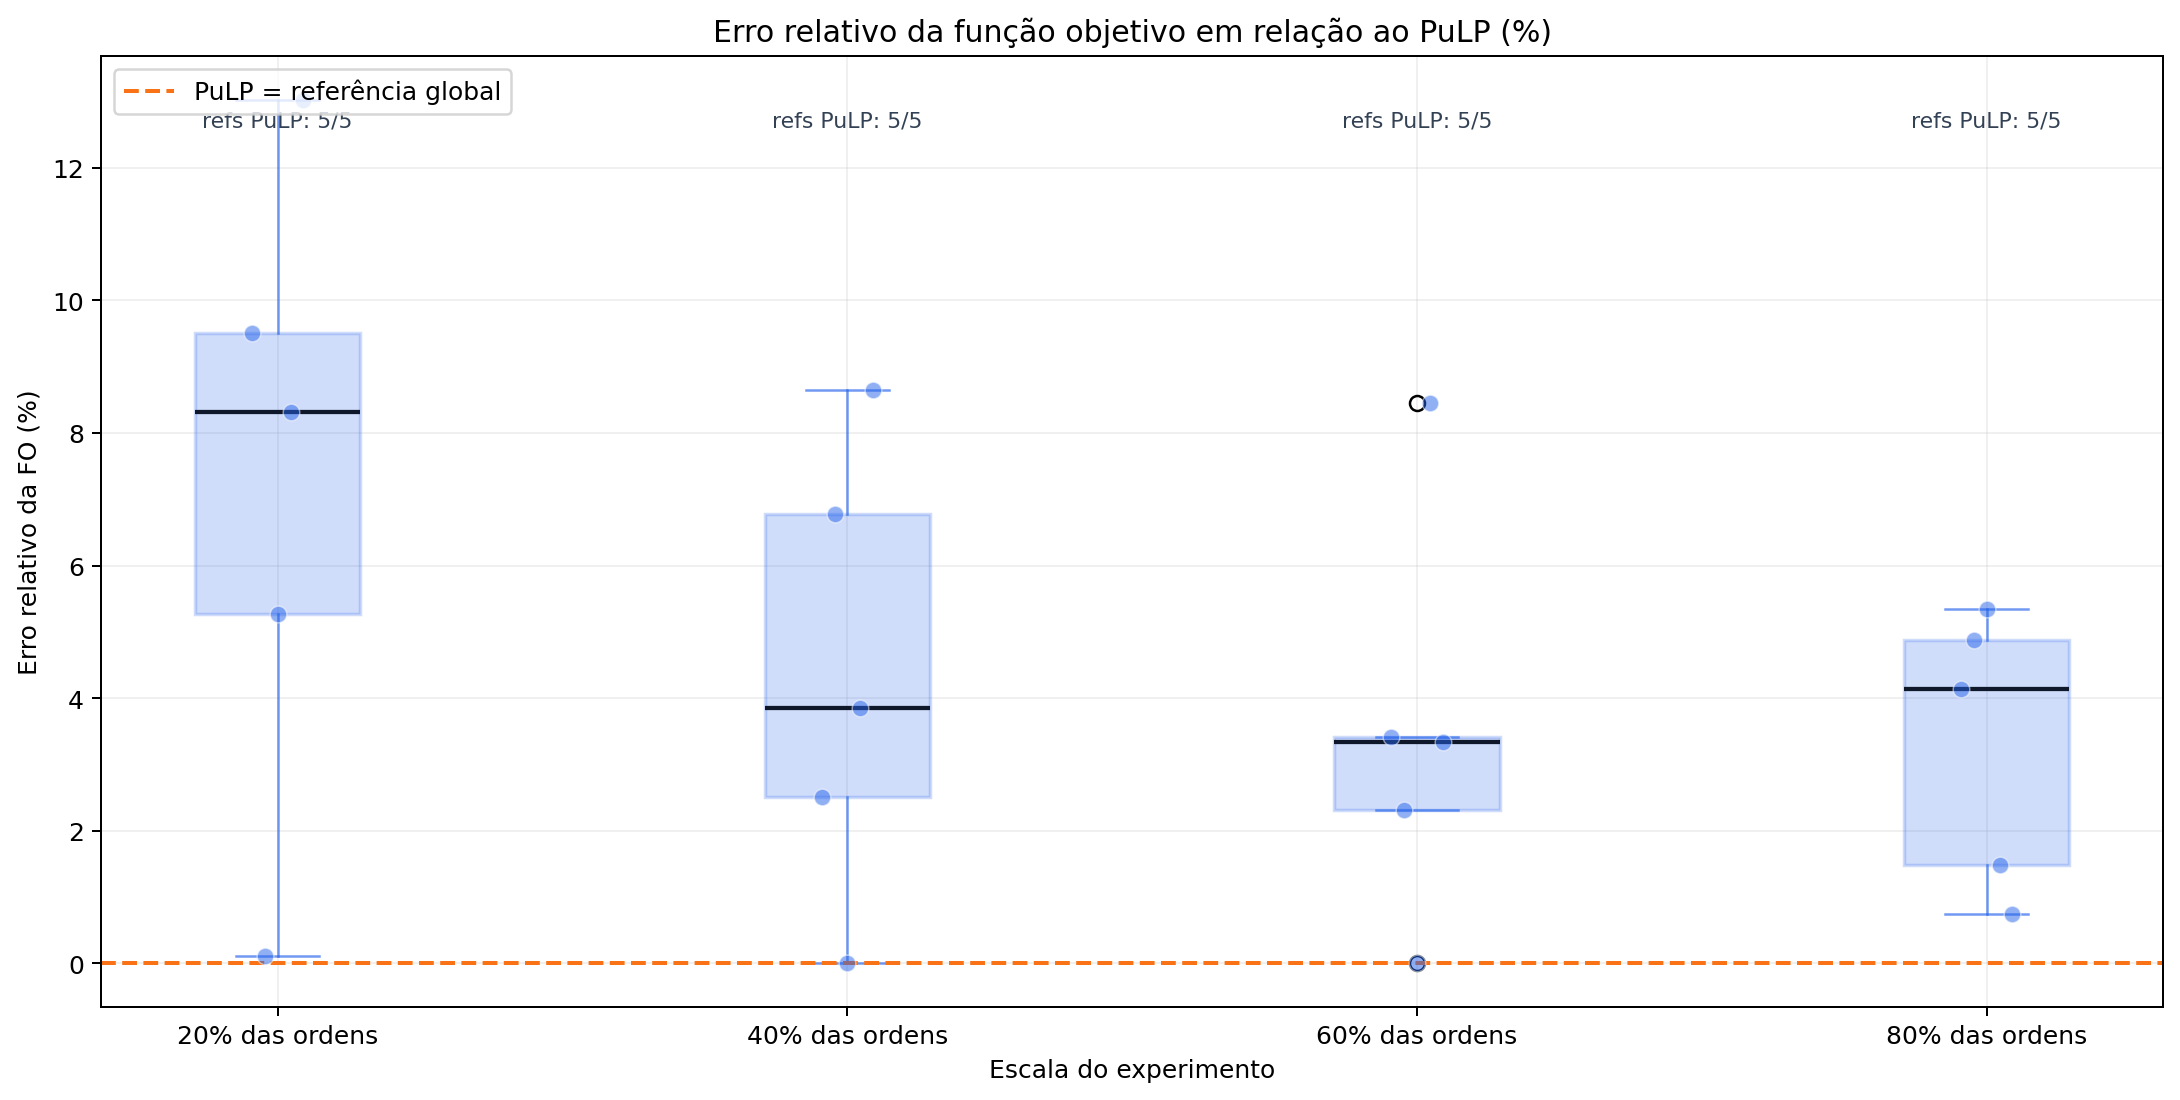

In [8]:
Image(filename=str(OUTPUT_DIR / 'plots' / 'erro_relativo_fo_pct.png'))

## 6. Qual foi a viabilidade do PuLP ao longo das escalas?

In [9]:
display(Markdown(rows_to_markdown_table(summarize_pulp_viability(SUMMARY))))

| Escala | Repeticoes | PuLP viável | Taxa de viabilidade do PuLP (%) | Referencias validas para erro de FO |
| --- | --- | --- | --- | --- |
| 20% das ordens | 5 | 5 | 100.0 | 5/5 |
| 40% das ordens | 5 | 5 | 100.0 | 5/5 |
| 60% das ordens | 5 | 5 | 100.0 | 5/5 |
| 80% das ordens | 5 | 5 | 100.0 | 5/5 |

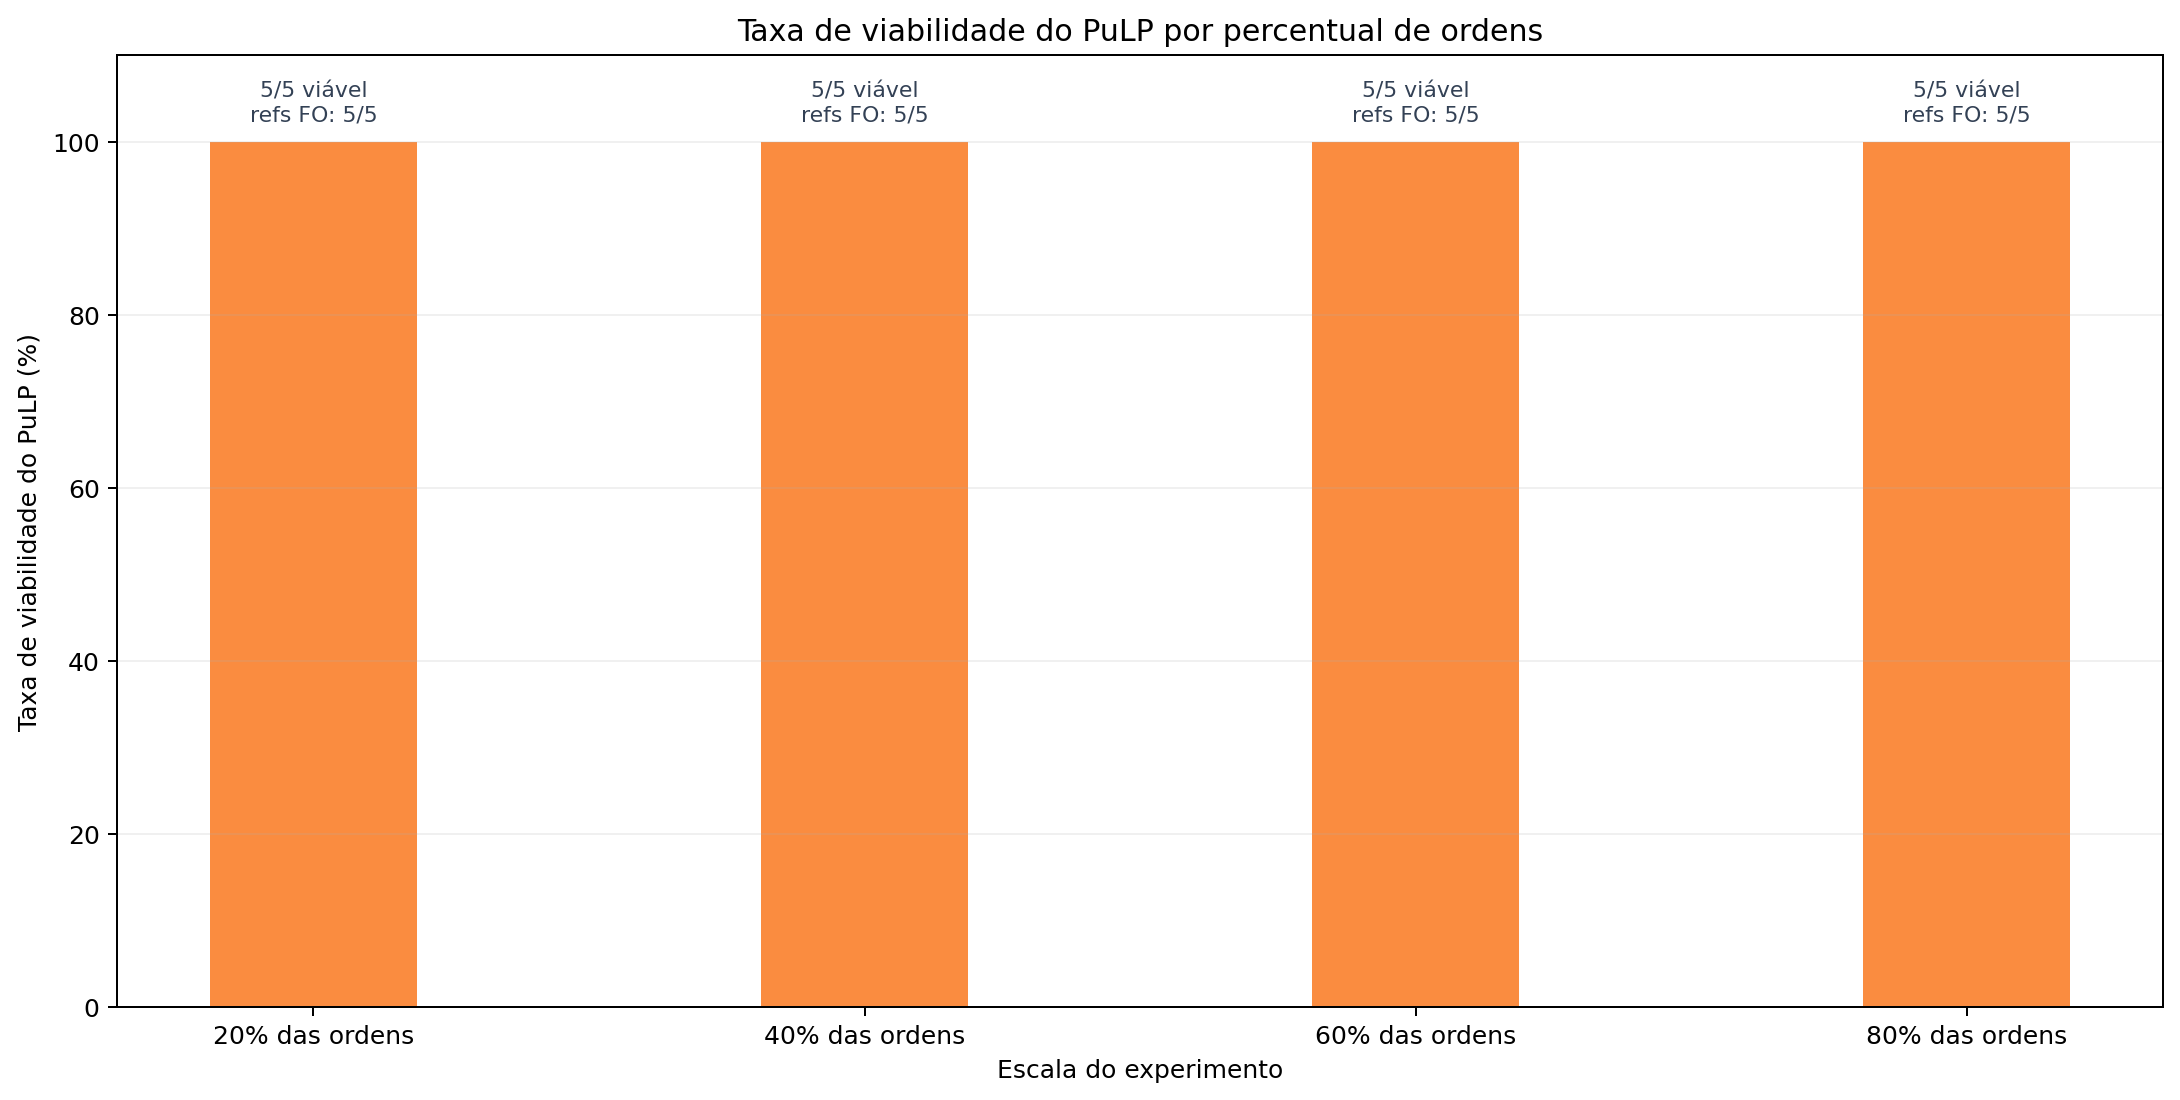

In [10]:
Image(filename=str(OUTPUT_DIR / 'plots' / 'taxa_viabilidade_pulp.png'))

## 7. Rodada Exaustiva - 100% das Ordens

In [11]:
display(Markdown('**Leitura correta desta secao**: `suprimento` e `recolhimento` continuam sendo executados como experimentos isolados. Os paineis e tabelas abaixo nao devem ser lidos como uma unica escala operacional acoplada de frota.'))

**Leitura correta desta secao**: `suprimento` e `recolhimento` continuam sendo executados como experimentos isolados. Os paineis e tabelas abaixo nao devem ser lidos como uma unica escala operacional acoplada de frota.

In [12]:
display(Markdown(rows_to_markdown_table(summarize_full_run(FULL_RUN))))

| Solver | Status | FO | Atendimento (%) | Viaturas | Distância total (km) | Duração total (min) | Escopo |
| --- | --- | --- | --- | --- | --- | --- | --- |
| PyVRP | feasible | 53089.16 | 100.00 | 13 | 339.39 | 670.5 | saldo agregado de duas execucoes isoladas por classe operacional |
| PuLP | feasible | 50197.62 | 100.00 | 10 | 326.21 | 642.1 | saldo agregado de duas execucoes isoladas por classe operacional |

In [13]:
display(Markdown(rows_to_markdown_table(summarize_full_run_by_class(FULL_RUN))))

| Solver | Classe operacional | Status | FO | Atendimento (%) | Viaturas | Distância total (km) | Duração total (min) |
| --- | --- | --- | --- | --- | --- | --- | --- |
| PyVRP | suprimento | feasible | 21832.93 | 100.00 | 7 | 130.64 | 261.2 |
| PyVRP | recolhimento | feasible | 31256.23 | 100.00 | 6 | 208.75 | 409.3 |
| PuLP | suprimento | Optimal | 19573.41 | 100.00 | 5 | 118.14 | 234.2 |
| PuLP | recolhimento | Optimal | 30624.21 | 100.00 | 5 | 208.07 | 408.0 |

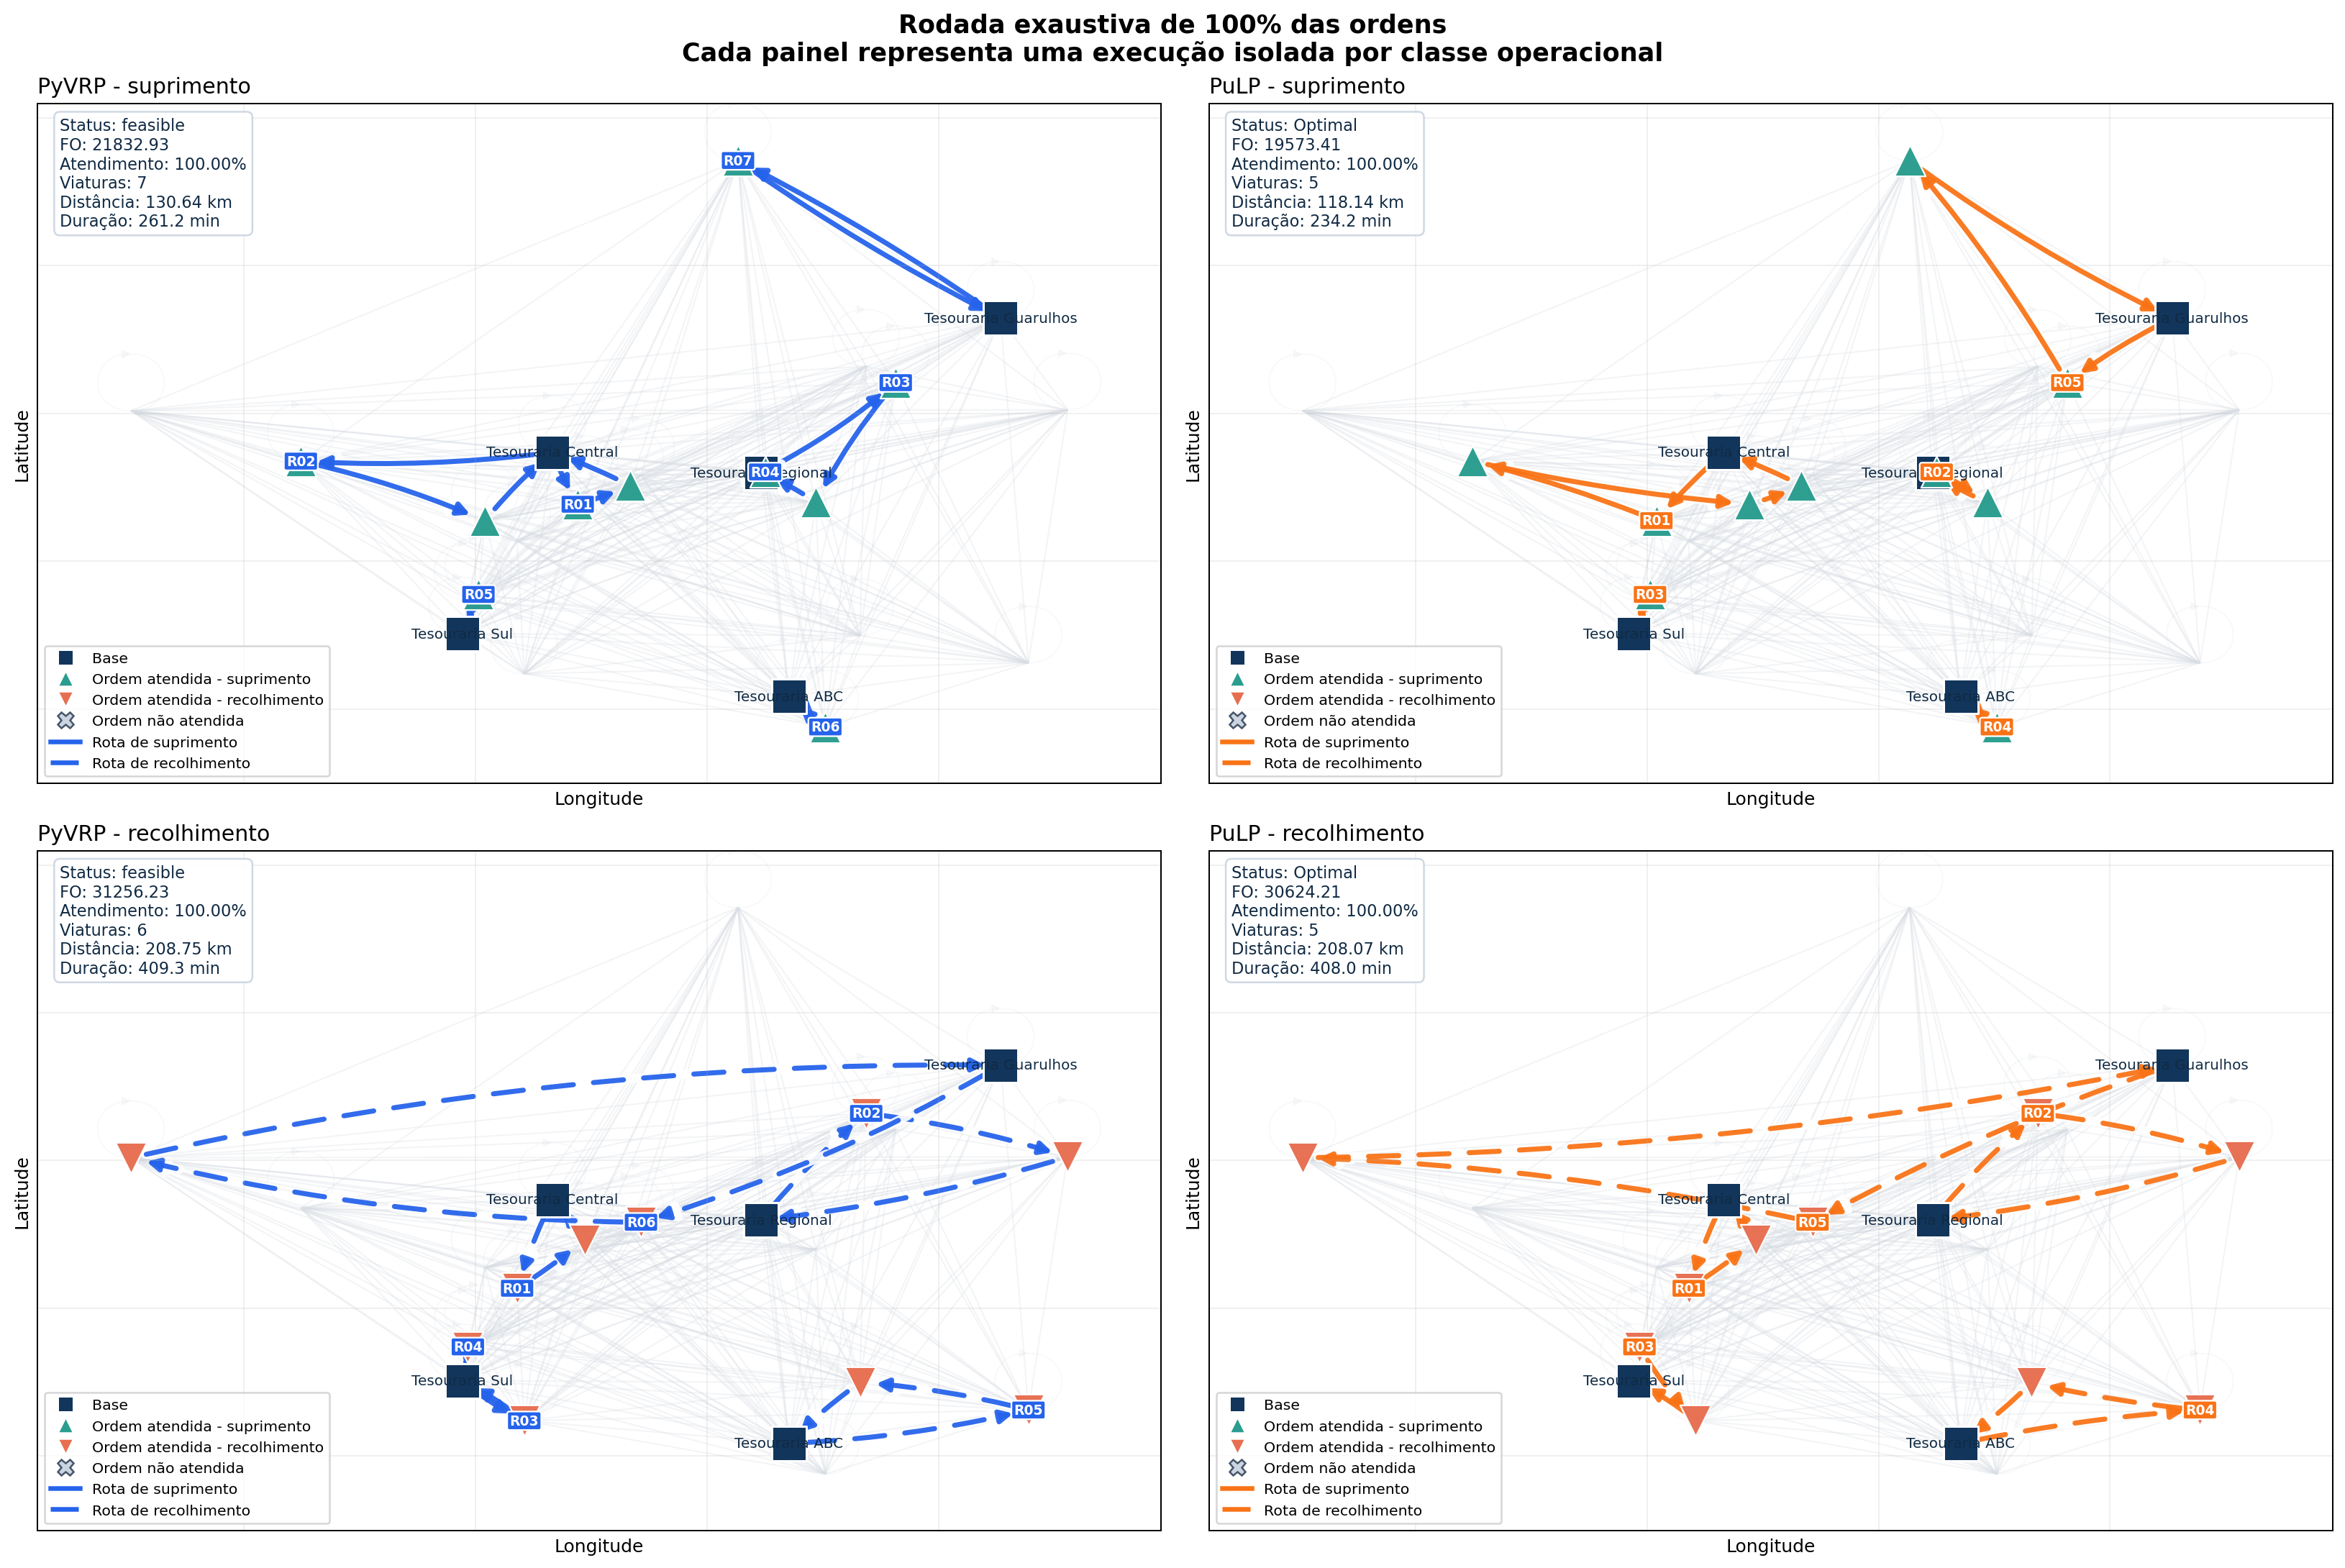

In [14]:
Image(filename=str(OUTPUT_DIR / 'plots' / 'rodada_exaustiva_100_rotas.png'))

### Rotas do PyVRP - suprimento

In [15]:
display(Markdown(rows_to_markdown_table(full_run_route_sequences(FULL_RUN, solver='pyvrp', classe_operacional='suprimento'))))

| Classe operacional | Rota | Viatura | Base | Paradas | Sequencia | Leitura correta | Distância (km) | Duração (min) |
| --- | --- | --- | --- | --- | --- | --- | --- | --- |
| suprimento | R01 | veh-V-CENTRO-01-suprimento | BASE-SP-CENTRO | 2 | Tesouraria Central - Barra Funda -> Agencia Itau - Av. Paulista -> Agencia Santander - Rua Direita -> Tesouraria Central - Barra Funda | execução isolada desta classe operacional | 13.75 | 27.0 |
| suprimento | R02 | veh-V-CENTRO-02-suprimento | BASE-SP-CENTRO | 2 | Tesouraria Central - Barra Funda -> Agencia BB - Osasco Centro -> Shopping Eldorado -> Tesouraria Central - Barra Funda | execução isolada desta classe operacional | 32.86 | 64.4 |
| suprimento | R03 | veh-V-LESTE-01-suprimento | BASE-SP-LESTE | 2 | Tesouraria Regional - Tatuape -> Internacional Shopping Guarulhos -> Shopping Analia Franco -> Tesouraria Regional - Tatuape | execução isolada desta classe operacional | 27.46 | 53.9 |
| suprimento | R04 | veh-V-LESTE-02-suprimento | BASE-SP-LESTE | 1 | Tesouraria Regional - Tatuape -> Agencia BB - Tatuape -> Tesouraria Regional - Tatuape | execução isolada desta classe operacional | 0.49 | 6.0 |
| suprimento | R05 | veh-V-SUL-01-suprimento | BASE-SP-SUL | 1 | Tesouraria Sul - Santo Amaro -> Shopping Morumbi -> Tesouraria Sul - Santo Amaro | execução isolada desta classe operacional | 7.62 | 14.9 |
| suprimento | R06 | veh-V-ABC-02-suprimento | BASE-SP-ABC | 1 | Tesouraria ABC - Sao Bernardo -> Agencia CEF - Centro SBC -> Tesouraria ABC - Sao Bernardo | execução isolada desta classe operacional | 7.01 | 13.7 |
| suprimento | R07 | veh-V-NORTE-02-suprimento | BASE-SP-NORTE | 1 | Tesouraria Guarulhos - Aeroporto -> Agencia CEF - Mairipora -> Tesouraria Guarulhos - Aeroporto | execução isolada desta classe operacional | 41.45 | 81.3 |

### Rotas do PyVRP - recolhimento

In [16]:
display(Markdown(rows_to_markdown_table(full_run_route_sequences(FULL_RUN, solver='pyvrp', classe_operacional='recolhimento'))))

| Classe operacional | Rota | Viatura | Base | Paradas | Sequencia | Leitura correta | Distância (km) | Duração (min) |
| --- | --- | --- | --- | --- | --- | --- | --- | --- |
| recolhimento | R01 | veh-V-CENTRO-01-recolhimento | BASE-SP-CENTRO | 2 | Tesouraria Central - Barra Funda -> Agencia Bradesco - Faria Lima -> Shopping Frei Caneca -> Tesouraria Central - Barra Funda | execução isolada desta classe operacional | 18.65 | 36.6 |
| recolhimento | R02 | veh-V-LESTE-01-recolhimento | BASE-SP-LESTE | 2 | Tesouraria Regional - Tatuape -> Agencia CEF - Centro Guarulhos -> Agencia Bradesco - Sao Miguel -> Tesouraria Regional - Tatuape | execução isolada desta classe operacional | 41.29 | 81.0 |
| recolhimento | R03 | veh-V-SUL-01-recolhimento | BASE-SP-SUL | 1 | Tesouraria Sul - Santo Amaro -> Agencia BB - Interlagos -> Tesouraria Sul - Santo Amaro | execução isolada desta classe operacional | 10.15 | 19.9 |
| recolhimento | R04 | veh-V-SUL-02-recolhimento | BASE-SP-SUL | 1 | Tesouraria Sul - Santo Amaro -> Agencia Santander - Chacara Sto Antonio -> Tesouraria Sul - Santo Amaro | execução isolada desta classe operacional | 6.42 | 12.6 |
| recolhimento | R05 | veh-V-ABC-01-recolhimento | BASE-SP-ABC | 2 | Tesouraria ABC - Sao Bernardo -> Maua Plaza Shopping -> Grand Plaza Shopping - Santo Andre -> Tesouraria ABC - Sao Bernardo | execução isolada desta classe operacional | 30.09 | 59.0 |
| recolhimento | R06 | veh-V-NORTE-01-recolhimento | BASE-SP-NORTE | 2 | Tesouraria Guarulhos - Aeroporto -> Mercado Municipal de Sao Paulo -> Agencia Itau - Alphaville -> Tesouraria Guarulhos - Aeroporto | execução isolada desta classe operacional | 102.14 | 200.3 |

### Rotas do PuLP - suprimento

In [17]:
display(Markdown(rows_to_markdown_table(full_run_route_sequences(FULL_RUN, solver='pulp', classe_operacional='suprimento'))))

| Classe operacional | Rota | Viatura | Base | Paradas | Sequencia | Leitura correta | Distância (km) | Duração (min) |
| --- | --- | --- | --- | --- | --- | --- | --- | --- |
| suprimento | R01 | veh-V-CENTRO-01-suprimento | BASE-SP-CENTRO | 4 | Tesouraria Central - Barra Funda -> Shopping Eldorado -> Agencia BB - Osasco Centro -> Agencia Itau - Av. Paulista -> Agencia Santander - Rua Direita -> Tesouraria Central - Barra Funda | execução isolada desta classe operacional | 43.44 | 85.2 |
| suprimento | R02 | veh-V-LESTE-02-suprimento | BASE-SP-LESTE | 2 | Tesouraria Regional - Tatuape -> Agencia BB - Tatuape -> Shopping Analia Franco -> Tesouraria Regional - Tatuape | execução isolada desta classe operacional | 8.34 | 18.9 |
| suprimento | R03 | veh-V-SUL-01-suprimento | BASE-SP-SUL | 1 | Tesouraria Sul - Santo Amaro -> Shopping Morumbi -> Tesouraria Sul - Santo Amaro | execução isolada desta classe operacional | 7.62 | 14.9 |
| suprimento | R04 | veh-V-ABC-01-suprimento | BASE-SP-ABC | 1 | Tesouraria ABC - Sao Bernardo -> Agencia CEF - Centro SBC -> Tesouraria ABC - Sao Bernardo | execução isolada desta classe operacional | 7.01 | 13.7 |
| suprimento | R05 | veh-V-NORTE-01-suprimento | BASE-SP-NORTE | 2 | Tesouraria Guarulhos - Aeroporto -> Internacional Shopping Guarulhos -> Agencia CEF - Mairipora -> Tesouraria Guarulhos - Aeroporto | execução isolada desta classe operacional | 51.73 | 101.4 |

### Rotas do PuLP - recolhimento

In [18]:
display(Markdown(rows_to_markdown_table(full_run_route_sequences(FULL_RUN, solver='pulp', classe_operacional='recolhimento'))))

| Classe operacional | Rota | Viatura | Base | Paradas | Sequencia | Leitura correta | Distância (km) | Duração (min) |
| --- | --- | --- | --- | --- | --- | --- | --- | --- |
| recolhimento | R01 | veh-V-CENTRO-01-recolhimento | BASE-SP-CENTRO | 2 | Tesouraria Central - Barra Funda -> Agencia Bradesco - Faria Lima -> Shopping Frei Caneca -> Tesouraria Central - Barra Funda | execução isolada desta classe operacional | 18.65 | 36.6 |
| recolhimento | R02 | veh-V-LESTE-01-recolhimento | BASE-SP-LESTE | 2 | Tesouraria Regional - Tatuape -> Agencia CEF - Centro Guarulhos -> Agencia Bradesco - Sao Miguel -> Tesouraria Regional - Tatuape | execução isolada desta classe operacional | 41.29 | 81.0 |
| recolhimento | R03 | veh-V-SUL-01-recolhimento | BASE-SP-SUL | 2 | Tesouraria Sul - Santo Amaro -> Agencia Santander - Chacara Sto Antonio -> Agencia BB - Interlagos -> Tesouraria Sul - Santo Amaro | execução isolada desta classe operacional | 15.89 | 31.2 |
| recolhimento | R04 | veh-V-ABC-01-recolhimento | BASE-SP-ABC | 2 | Tesouraria ABC - Sao Bernardo -> Maua Plaza Shopping -> Grand Plaza Shopping - Santo Andre -> Tesouraria ABC - Sao Bernardo | execução isolada desta classe operacional | 30.09 | 59.0 |
| recolhimento | R05 | veh-V-NORTE-01-recolhimento | BASE-SP-NORTE | 2 | Tesouraria Guarulhos - Aeroporto -> Mercado Municipal de Sao Paulo -> Agencia Itau - Alphaville -> Tesouraria Guarulhos - Aeroporto | execução isolada desta classe operacional | 102.14 | 200.3 |

## 8. Qual leitura metodologica deve ir para o slide final?

In [19]:
display(Markdown(build_benchmark_takeaway(SUMMARY)))

O benchmark amostral confirma o trade-off esperado entre controle de otimalidade e escalabilidade. No recorte de 80% das ordens, o PyVRP teve tempo médio de 1.4300s, enquanto o PuLP exigiu 114.0907s. A taxa média de atendimento permaneceu em 100.00% para o PyVRP e 100.00% para o PuLP. Nas repetições com referência válida do PuLP em 80% das ordens, o erro relativo mediano da FO do PyVRP foi 4.1393%. Na rodada exaustiva de 100% das ordens, o PyVRP fechou com status feasible e o PuLP com status feasible.